<a href="https://colab.research.google.com/github/madelinelebreton/galicia-climate-analysis/blob/main/map_AEMET_stations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Install required packages and load required libraries**

In [6]:
install.packages(c("climaemet", "ggplot2", "sf", "tidygeocoder", "dplyr"))

library(climaemet)
library(ggplot2)
library(sf)
library(dplyr)
library(giscoR)


**Authenticate with your AEMET OpenData API Key**

(Get a free key here if needed: https://opendata.aemet.es/centrodedescargas/altaUsuario)

In [ ]:
aemet_api_key("your_API_key", install = TRUE)

**Get borderlines of Spain and Galicia from Eurostat**

Ensure they both use the same coordinate reference system (CRS)


In [18]:
spain_outline <- gisco_get_nuts(
  country = "Spain",
  nuts_level = 1,
  resolution = "01"
)

galicia_outline <- gisco_get_nuts(
  country = "Spain",
  nuts_level = 2,
  resolution = "01"
) %>%
  filter(NUTS_NAME == "Galicia")

galicia_outline <- st_transform(galicia_outline, crs = st_crs(galicia_stations))


**Get AEMET stations as a spatial Simple Features (sf) object**

In [ ]:
all_stations_sf <- aemet_stations(return_sf = TRUE)

**Crop the data to mainland Spain for clarity**

Uses latitude and longitude limits

In [ ]:
cropped_map <- st_crop(spain_outline, c(xmin = -10.0, ymin = 35.0, xmax = 4.5, ymax = 44.0))
cropped_data <- st_crop(all_stations_sf, c(xmin = -10.0, ymin = 35.0, xmax = 4.5, ymax = 44.0))

**Plot the map of Spain**

Uses the borders as a background and maps the points on top, then adds labels

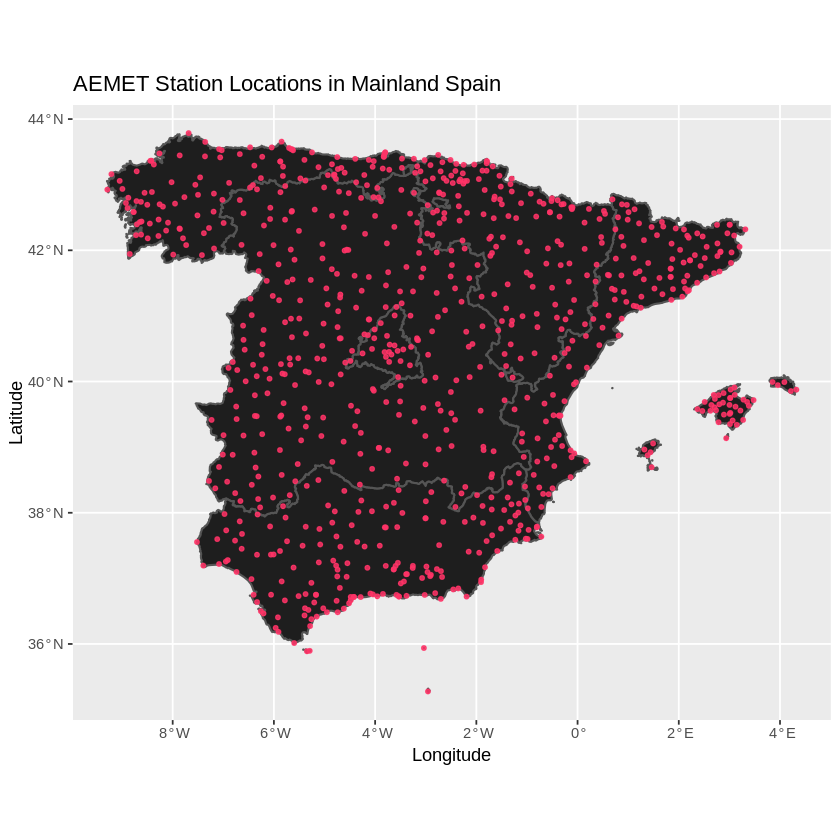

In [23]:

ggplot(data = cropped_data) +
  geom_sf(data = cropped_map, fill = "#1e1e1e", color = "#555555", linewidth = 0.6) +
  geom_sf(color = "#FF3366", size = 1, alpha = 0.85) +

  labs(
    title = "AEMET Station Locations in Mainland Spain",
    x = "Longitude",
    y = "Latitude"
  )

**Filter for stations in the provinces of Galicia**

In [9]:
galicia_provinces <- c("A CORUÑA", "LUGO", "OURENSE", "PONTEVEDRA")

galicia_stations <- all_stations_sf %>%
  filter(provincia %in% galicia_provinces)


**Plot a zoomed-in map of Galicia with station IDs**

Warning message in st_point_on_surface.sfc(sf::st_zm(x)):
“st_point_on_surface may not give correct results for longitude/latitude data”


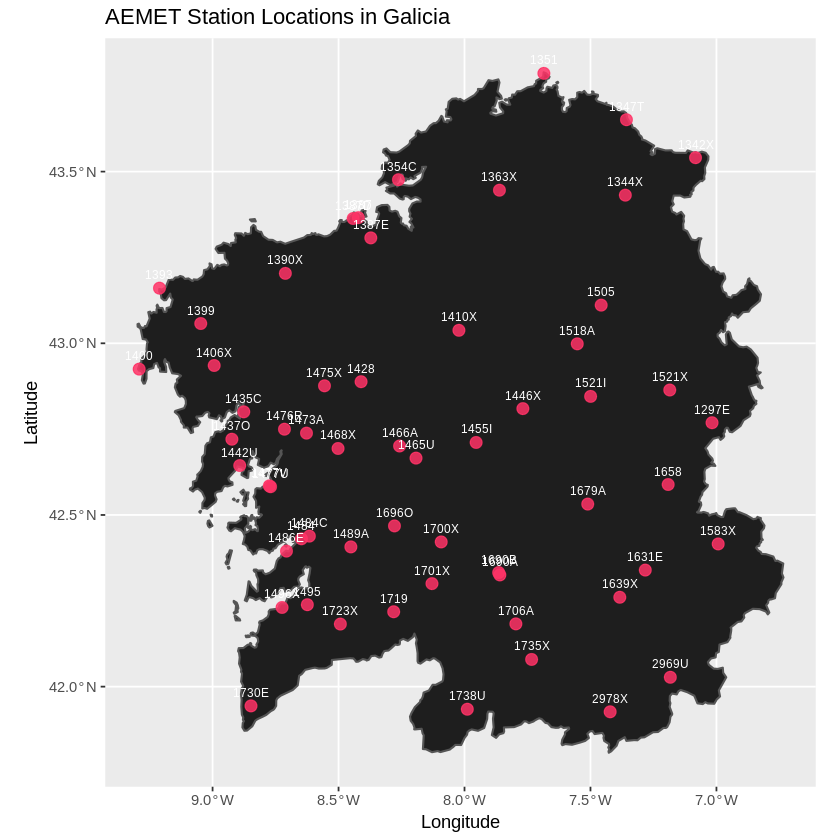

In [24]:
ggplot(data = galicia_stations) +
  geom_sf(data = galicia_outline, fill = "#1e1e1e", color = "#555555", linewidth = 0.6) +
  geom_sf(color = "#FF3366", size = 3, alpha = 0.85) +
  geom_sf_text(aes(label = indicativo), size = 2.5, vjust = -1, color = "white") +

  labs(
    title = "AEMET Station Locations in Galicia",
    x = "Longitude",
    y = "Latitude"
  )